# New

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import h5py
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import json
from sklearn.metrics import (classification_report, average_precision_score,
                            confusion_matrix)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/data/"

Using device: cuda
Mounted at /content/drive


### Data Preprocessing

In [2]:
def load_label_mapping(mapping_path):
    with open(mapping_path, 'r') as f:
        mapping = json.load(f)
    print(f"classes: {mapping['n_classes']}")
    print(f"labels: {list(mapping['label_to_idx'].items())[:]}")
    return mapping

label_mapping = load_label_mapping(BASE_DIR+'label_mapping.json')
n_classes = label_mapping['n_classes']

classes: 15
labels: [('Abies', 0), ('Acer', 1), ('Alnus', 2), ('Betula', 3), ('Cleared', 4), ('Fagus', 5), ('Fraxinus', 6), ('Larix', 7), ('Picea', 8), ('Pinus', 9), ('Populus', 10), ('Prunus', 11), ('Pseudotsuga', 12), ('Quercus', 13), ('Tilia', 14)]


### Dataloader / Augmentation

In [3]:
class H5Dataset(Dataset):
    def __init__(self, h5_path: str):
        self.h5f = h5py.File(h5_path, 'r')
        self.images = self.h5f['images']
        self.labels = self.h5f['labels']
        self.valid_indices = self._filter_nan_samples()
        self.n_samples = len(self.valid_indices)
        print(f"H5Dataset initialized: {h5_path}")
        print(f"Total samples: {len(self.labels)}")
        print(f"Valid samples: {self.n_samples}")

    def _filter_nan_samples(self):
        valid_indices = []
        for idx in range(len(self.h5f['labels'])):
            img = self.images[idx].astype(np.float32)
            input_bands = img[1:3]  # VV, VH
            if not np.isnan(input_bands).any():
                valid_indices.append(idx)
        return valid_indices

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        img = self.images[actual_idx].astype(np.float32).copy()
        input_bands = img[1:3]  # VV, VH
        label = int(self.labels[actual_idx])

        vv = torch.from_numpy(input_bands[0])  # [H, W]
        vh = torch.from_numpy(input_bands[1])  # [H, W]
        image = torch.stack([vv, vh], dim=0)   # [2, H, W]

        label = torch.tensor(label, dtype=torch.long)
        return image, label

    def get_filename(self, idx):
        actual_idx = self.valid_indices[idx]
        return self.images.file['filenames'][actual_idx].decode('utf-8')

    def get_label_name(self, idx):
        actual_idx = self.valid_indices[idx]
        return self.images.file['label_names'][actual_idx].decode('utf-8')

    def close(self):
        if hasattr(self, 'h5f'):
            self.h5f.close()

    def __del__(self):
        self.close()

def create_dataloaders(
    train_h5: str,
    test_h5: str,
    batch_size: int = 128,
    num_workers: int = 4,
    val_ratio: float = 0.1
):
    train_dataset = H5Dataset(train_h5)
    test_dataset = H5Dataset(test_h5)

    original_train_size = len(train_dataset)
    val_size = int(original_train_size * val_ratio)
    train_size = original_train_size - val_size

    torch.manual_seed(42)
    train_indices, val_indices = random_split(
        range(original_train_size),
        [train_size, val_size]
    )

    train_subset = torch.utils.data.Subset(train_dataset, train_indices.indices)
    val_dataset = torch.utils.data.Subset(train_dataset, val_indices.indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    return train_loader, val_loader, test_loader, train_dataset

In [92]:
batch_size = 128
train_loader, val_loader, test_loader, full_train_dataset = create_dataloaders(
    train_h5=BASE_DIR + 'train_data.h5',
    test_h5=BASE_DIR + 'test_data.h5',
    batch_size=batch_size,
    num_workers=4,
    val_ratio=0.1
)

H5Dataset initialized: /content/drive/MyDrive/data/train_data.h5
Total samples: 45337
Valid samples: 45314
H5Dataset initialized: /content/drive/MyDrive/data/test_data.h5
Total samples: 5044
Valid samples: 5041


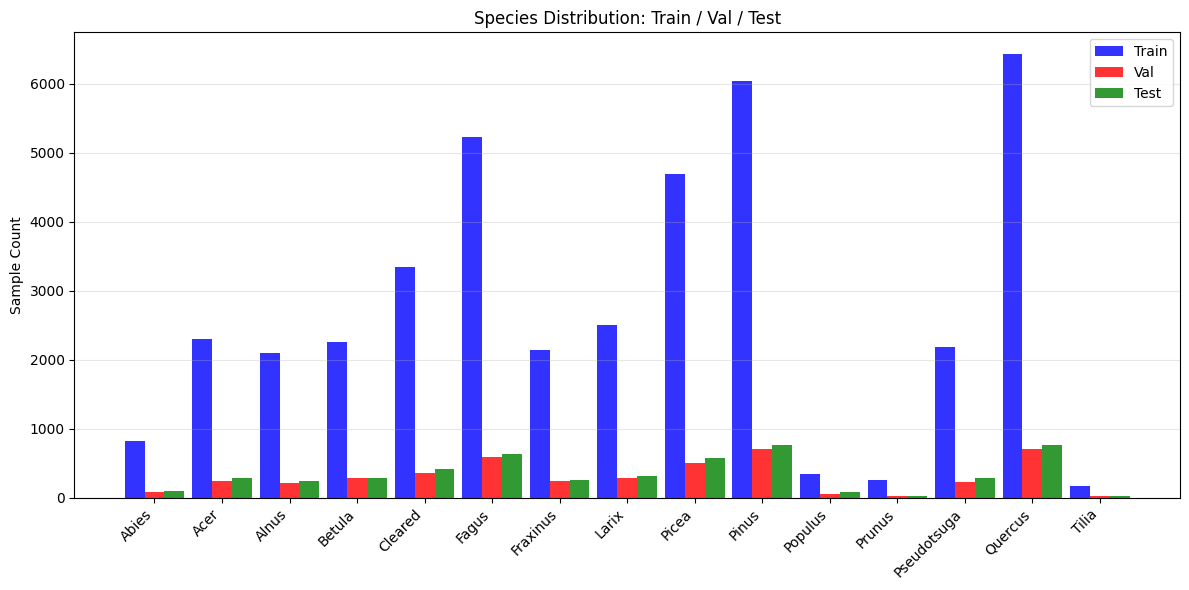

In [6]:
def plot_species_distribution(train_loader, val_loader, test_loader, label_mapping, num_classes):
    """绘制train、val、test set的按树种分布条形图"""
    # 统计每个数据集的类别分布
    def count_labels(loader, num_classes):
        counts = torch.zeros(num_classes, dtype=torch.long)
        for _, labels in loader:
            for label in labels:
                counts[label.item()] += 1
        return counts.numpy()

    train_counts = count_labels(train_loader, num_classes)
    val_counts = count_labels(val_loader, num_classes)
    test_counts = count_labels(test_loader, num_classes)

    # 获取类别名称
    if label_mapping and 'idx_to_label' in label_mapping:
        idx_to_label = label_mapping['idx_to_label']
        if isinstance(list(idx_to_label.keys())[0], str):
            idx_to_label = {int(k): v for k, v in idx_to_label.items()}
        class_names = [idx_to_label.get(i, f'Class_{i}') for i in range(num_classes)]
    else:
        class_names = [f'Class_{i}' for i in range(num_classes)]

    # 设置条形图参数
    n_classes = num_classes
    bar_width = 0.25  # 每个bar的宽度
    group_width = bar_width * 3  # 每组（train+val+test）的总宽度
    group_spacing = 0.1  # 组之间的间距

    # 计算每个组的起始位置
    x_positions = []
    for i in range(n_classes):
        start_pos = i * (group_width + group_spacing)
        x_positions.append([start_pos, start_pos + bar_width, start_pos + 2 * bar_width])

    fig, ax = plt.subplots(figsize=(max(12, n_classes * 0.8), 6))

    colors = ['blue', 'red', 'green']  # train, val, test

    labels = ['Train', 'Val', 'Test']

    for i in range(n_classes):
        values = [train_counts[i], val_counts[i], test_counts[i]]
        for j, (val, color, label) in enumerate(zip(values, colors, labels)):
            ax.bar(x_positions[i][j], val, bar_width, color=color, label=label if i == 0 else '', alpha=0.8)

    ax.set_xticks([pos[1] for pos in x_positions])
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylabel('Sample Count')
    ax.set_title('Species Distribution: Train / Val / Test')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


# 绘制train/val/test的树种分布
plot_species_distribution(train_loader, val_loader, test_loader, label_mapping, n_classes)

### UNet++ Model

In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels, momentum=0.01),
            nn.GELU(),
            nn.Dropout2d(dropout),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels, momentum=0.01),
            nn.GELU()
        )

    def forward(self, x):
        return self.conv(x)

In [15]:

class UNetPlusPlus(nn.Module):
    """
    UNet++ for classification tasks(Nested skip connection), adapted for 6×6 small patches
    Input: (B, 2, 6, 6)
    Output: (B, 15)
    Only two pooling layers are possible
    """

    def __init__(self, in_channels=2, num_classes=15, base_channels=32, dropout=0.3):
        super().__init__()

        # configure the number of channels
        nb_filter = [base_channels, base_channels*2, base_channels*4]
        self.pool = nn.MaxPool2d(2, 2)

        self.conv0_0 = ConvBlock(in_channels, nb_filter[0], dropout)
        self.conv1_0 = ConvBlock(nb_filter[0], nb_filter[1], dropout)
        self.conv0_1 = ConvBlock(nb_filter[0] + nb_filter[1], nb_filter[0], dropout)
        self.conv2_0 = ConvBlock(nb_filter[1], nb_filter[2], dropout)
        self.conv1_1 = ConvBlock(nb_filter[1] + nb_filter[2], nb_filter[1], dropout)
        self.conv0_2 = ConvBlock(nb_filter[0]*2 + nb_filter[1], nb_filter[0], dropout)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(nb_filter[0] * 2 + nb_filter[2], base_channels * 4),  # 融合3个输出
            nn.BatchNorm1d(base_channels * 4, momentum=0.01),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(base_channels * 4, base_channels * 2),
            nn.BatchNorm1d(base_channels * 2, momentum=0.01),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),

            nn.Linear(base_channels * 2, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # encoder
        x0_0 = self.conv0_0(x)  # (B, 32, 6, 6)
        x1_0 = self.conv1_0(self.pool(x0_0))  # (B, 64, 3, 3)

        # nested nodes
        x0_1 = self.conv0_1(torch.cat([x0_0, F.interpolate(x1_0, size=x0_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 32, 6, 6)

        # bottleneck
        x2_0 = self.conv2_0(self.pool(x1_0))  # (B, 128, 1, 1)

        # decoder
        x1_1 = self.conv1_1(torch.cat([x1_0, F.interpolate(x2_0, size=x1_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 64, 3, 3)
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, F.interpolate(x1_1, size=x0_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 32, 6, 6)

        # deep supervision, feature fusion
        out0_1 = self.global_pool(x0_1).flatten(1)  # (B, 32)
        out0_2 = self.global_pool(x0_2).flatten(1)  # (B, 32)
        out_bottleneck = self.global_pool(x2_0).flatten(1)  # (B, 128)

        multi_scale_features = torch.cat([
            out0_1, out0_2, out_bottleneck
        ], dim=1)  # (B, 32+32+128) = (B, 192)

        # clf
        logits = self.classifier(multi_scale_features)

        return logits

### Loss

In [54]:
class PseudoHuberLoss(nn.Module):
    def __init__(self, delta=1.0, alpha=None):
        super(PseudoHuberLoss, self).__init__()
        self.delta = delta

        if alpha is None:
            self.alpha = None
        elif isinstance(alpha, (float, int)):
            self.alpha = torch.tensor([alpha])
        else:
            self.alpha = alpha if isinstance(alpha, torch.Tensor) else torch.tensor(alpha)

    def forward(self, inputs, targets):
        """
        inputs: [B, C] logits
        targets: [B] class indices
        """
        # 先计算交叉熵作为基础误差
        ce_loss = F.cross_entropy(inputs, targets)  # [B]

        # 应用Pseudo-Huber变换: δ² * (√(1 + (x/δ)²) - 1)
        delta_sq = self.delta ** 2
        normalized_loss = ce_loss / self.delta
        ph_loss = delta_sq * (torch.sqrt(1 + normalized_loss ** 2) - 1)

        # 应用类别权重
        if self.alpha is not None:
            if self.alpha.device != inputs.device:
                self.alpha = self.alpha.to(inputs.device)
            alpha_t = self.alpha[targets]
            ph_loss = alpha_t * ph_loss

        # 应用reduction
        return ph_loss.mean()

In [45]:
def compute_class_weights(dataloader, num_classes, method='inverse', beta=0.9999):
    class_counts = torch.zeros(num_classes, dtype=torch.long)

    for _, labels in tqdm(dataloader, desc="Counting labels"):
        for label in labels:
            class_counts[label.item()] += 1

    total_samples = class_counts.sum().item()

    if method == 'inverse':
        weights = 1.0 / class_counts.float()
    elif method == 'balanced':
        weights = total_samples / (num_classes * class_counts.float())
    elif method == 'effective':
        effective_num = 1.0 - torch.pow(beta, class_counts.float())
        weights = (1.0 - beta) / effective_num
    else:
        raise ValueError(f"Unknown method: {method}")

    weights = weights / weights.mean()
    return weights

### Function

In [46]:
def compute_accuracy(pred, target):
    pred_labels = torch.argmax(pred, dim=1)  # [B]
    correct = (pred_labels == target).float()  # [B]
    total = target.size(0)
    accuracy = correct.sum().item() / total if total > 0 else 0.0
    return accuracy

def compute_map(pred, target, num_classes):
    probs = torch.softmax(pred, dim=1).cpu().numpy()  # [B, num_classes]
    target_np = target.cpu().numpy()  # [B]
    if len(target_np) == 0:
        return 0.0
    target_onehot = np.eye(num_classes)[target_np]  # [B, num_classes]
    aps = []
    for i in range(num_classes):
        if target_onehot[:, i].sum() > 0:
            try:
                ap = average_precision_score(target_onehot[:, i], probs[:, i])
                aps.append(ap)
            except:
                continue
    return np.mean(aps) if len(aps) > 0 else 0.0

def collect_layer_gradients(model):
    layer_grads = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_mean_abs = param.grad.abs().mean().item()
            layer_grads[name] = grad_mean_abs
    return layer_grads

In [68]:
def train_random_batches(model, train_dataset, criterion, optimizer, scheduler, device, epoch, batch_size,
                               steps_per_epoch=50, total_batches=None, return_grads=False):
    """
    Random batch selection. Fixed steps per epoch.
    """
    model.train()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    total_samples = len(train_dataset) # create indices for random batch selection
    pbar = tqdm(range(steps_per_epoch), desc=f"Epoch {epoch+1}")

    for step in pbar:
        indices = torch.randint(0, total_samples, (batch_size,)) # Randomly select batch indices
        batch_data = []
        batch_labels = []

        for idx in indices:
            data, label = train_dataset[idx.item()]
            batch_data.append(data)
            batch_labels.append(label)

        data = torch.stack(batch_data).to(device)
        target = torch.stack(batch_labels).to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        if return_grads and step == steps_per_epoch - 1:
            layer_grads = collect_layer_gradients(model) # for the last batch

        optimizer.step()
        with torch.no_grad():
            acc = compute_accuracy(output, target)

        total_loss += loss.item()
        total_acc += acc
        n_batches += 1

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{acc*100:.1f}%'
        })

    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches

    if return_grads:
        return avg_loss, avg_acc, layer_grads
    return avg_loss, avg_acc

In [48]:
# def train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device, epoch,
#                                 return_grads=False):
#     """
#     Training function using DataLoader (standard training):
#     - Iterates through all batches in the loader
#     - Uses DataLoader's shuffle and batching
#     """
#     model.train()
#     total_loss = 0
#     total_acc = 0
#     n_batches = 0

#     pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

#     for batch_idx, (data, target) in enumerate(pbar):
#         data = data.to(device)
#         target = target.to(device)

#         optimizer.zero_grad()
#         output = model(data)
#         loss = criterion(output, target)
#         loss.backward()

#         # Gradient clipping for stability
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         if return_grads and batch_idx == len(train_loader) - 1:
#             layer_grads = collect_layer_gradients(model)

#         optimizer.step()

#         with torch.no_grad():
#             acc = compute_accuracy(output, target)

#         total_loss += loss.item()
#         total_acc += acc
#         n_batches += 1

#         pbar.set_postfix({
#             'Loss': f'{loss.item():.4f}',
#             'Acc': f'{acc*100:.1f}%'
#         })

#     avg_loss = total_loss / n_batches
#     avg_acc = total_acc / n_batches

#     if return_grads:
#         return avg_loss, avg_acc, layer_grads
#     return avg_loss, avg_acc

In [49]:
def evaluate_classification(model, loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")
        for batch_data in pbar:
            data, target = batch_data
            data = data.to(device)
            target = target.to(device)

            # forward
            output = model(data)
            loss = criterion(output, target)

            pred = output.argmax(dim=1)
            correct = (pred == target).sum().item()
            batch_acc = correct / target.size(0)

            total_loss += loss.item() * target.size(0)
            total_correct += correct
            total_samples += target.size(0)

            all_preds.append(output.detach().cpu())
            all_targets.append(target.cpu())

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{batch_acc*100:.1f}%'
            })

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    mAP = compute_map(all_preds, all_targets, num_classes)

    return avg_loss, avg_acc, mAP

### Train

In [94]:
# Compute class weights
class_weights = compute_class_weights(
    train_loader,
    num_classes=n_classes,
    method='effective',
    beta=0.99999
)

Counting labels: 100%|██████████| 319/319 [00:01<00:00, 242.67it/s]


In [139]:
# Initialize UNet++ model
model = UNetPlusPlus(in_channels=2, num_classes=n_classes, base_channels=32, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 552,399
Trainable parameters: 552,399


In [140]:
# Pseudo-Huber Loss with class weights
criterion = PseudoHuberLoss(delta=0.1, alpha=class_weights)

# Adam optimizer with low learning rate (as per paper)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,  # Low learning rate as specified in paper
    weight_decay=1e-4  # Weight regularization to reduce overfitting
)

In [141]:
# Paper specifications:
# - 5,000 epochs
# - 50 steps per epoch
# - Reduce LR by 10% every 100 epochs when plateau is reached
num_epochs = 100 # 5000
steps_per_epoch = 100

# Learning rate scheduler: reduce by 10% every 100 epochs on plateau
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.9,  # Reduce by 10%
    patience=50,  # Wait 100 epochs before reducing
    min_lr=1e-7
)

best_val_loss = float('inf')
best_val_acc = 0.0
best_val_map = 0.0
patience_counter = 0
early_stop_patience = 200  # Increased for long training

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_map': [], 'lr': [],
    'layer_grads': {}
}

print(f"Model: UNet++")
print(f"Epochs: {num_epochs}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Batch size: 128")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']:.2e}")
print(f"LR reduction: 10% every 100 epochs on plateau")
print(f"Loss: Pseudo-Huber (delta=0.1)")
print(f"Optimizer: Adam with weight decay={optimizer.param_groups[0]['weight_decay']}")

Model: UNet++
Epochs: 100
Steps per epoch: 100
Batch size: 128
Initial learning rate: 1.00e-04
LR reduction: 10% every 100 epochs on plateau
Loss: Pseudo-Huber (delta=0.1)
Optimizer: Adam with weight decay=0.0001


In [ ]:
for epoch in range(num_epochs):
    train_loss, train_acc, layer_grads = train_random_batches(
        model, full_train_dataset, criterion, optimizer, scheduler, device, epoch, batch_size,
        steps_per_epoch=steps_per_epoch, return_grads=True
    )

    # train_loss, train_acc, layer_grads = train_one_epoch(
    #     model, train_loader, criterion, optimizer, scheduler, device, epoch,
    #     return_grads=True
    # )

    val_loss, val_acc, val_map = evaluate_classification(
        model, val_loader, criterion, device, n_classes
    )

    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)

    for layer_name, grad_value in layer_grads.items():
        if layer_name not in history['layer_grads']:
            history['layer_grads'][layer_name] = []
        history['layer_grads'][layer_name].append(grad_value)

    # Print every 10 epochs to reduce output
    if (epoch + 1) % 4 == 0 or epoch < 4:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}% | Val mAP: {val_map:.4f} | LR: {current_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_map = val_map
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_map': val_map,
            'history': history
        }, 'best_unetpp_model.pth')

        if (epoch + 1) % 4 == 0 or epoch < 4:
            print(f" *Best model | mAP: {best_val_map:.4f}, Acc: {best_val_acc*100:.2f}%, Loss: {best_val_loss:.4f}\n")
    else:
        patience_counter += 1
        if (epoch + 1) % 4 == 0 or epoch < 4:
            print(f"Patience: {patience_counter}/{early_stop_patience}\n")

    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Evaluating: 100%|██████████| 36/36 [00:00<00:00, 80.75it/s, Loss=0.0576, Acc=17.6%]


Epoch 1/100
  Train Loss: 0.1188 | Train Acc: 8.30%
  Val Loss:   0.0811 | Val Acc:   12.20% | Val mAP: 0.0769 | LR: 1.00e-04
 *Best model | mAP: 0.0769, Acc: 12.20%, Loss: 0.0811



Evaluating: 100%|██████████| 36/36 [00:00<00:00, 79.77it/s, Loss=0.0562, Acc=27.5%]


Epoch 2/100
  Train Loss: 0.1044 | Train Acc: 10.42%
  Val Loss:   0.0784 | Val Acc:   20.94% | Val mAP: 0.1013 | LR: 1.00e-04
 *Best model | mAP: 0.1013, Acc: 20.94%, Loss: 0.0784



Evaluating: 100%|██████████| 36/36 [00:00<00:00, 77.33it/s, Loss=0.0570, Acc=19.6%]


...

Evaluating: 100%|██████████| 36/36 [00:00<00:00, 81.91it/s, Loss=0.0565, Acc=15.7%]


Epoch 4/100
  Train Loss: 0.0924 | Train Acc: 13.34%
  Val Loss:   0.0758 | Val Acc:   23.15% | Val mAP: 0.1107 | LR: 1.00e-04
 *Best model | mAP: 0.1107, Acc: 23.15%, Loss: 0.0758



Evaluating: 100%|██████████| 36/36 [00:00<00:00, 80.50it/s, Loss=0.0547, Acc=15.7%]


Epoch 8/100
  Train Loss: 0.0828 | Train Acc: 17.38%
  Val Loss:   0.0736 | Val Acc:   22.51% | Val mAP: 0.1067 | LR: 1.00e-04
Patience: 4/200



Epoch 11:  47%|████▋     | 47/100 [00:01<00:01, 52.11it/s, Loss=0.0849, Acc=20.3%]

### *** Quick Check

In [101]:
print(f"Best Validation Results:")
print(f"  mAP: {best_val_map:.4f}")
print(f"  Accuracy: {best_val_acc*100:.2f}%")
print(f"  Loss: {best_val_loss:.4f}")

Best Validation Results:
  mAP: 0.3745
  Accuracy: 50.94%
  Loss: 0.0477


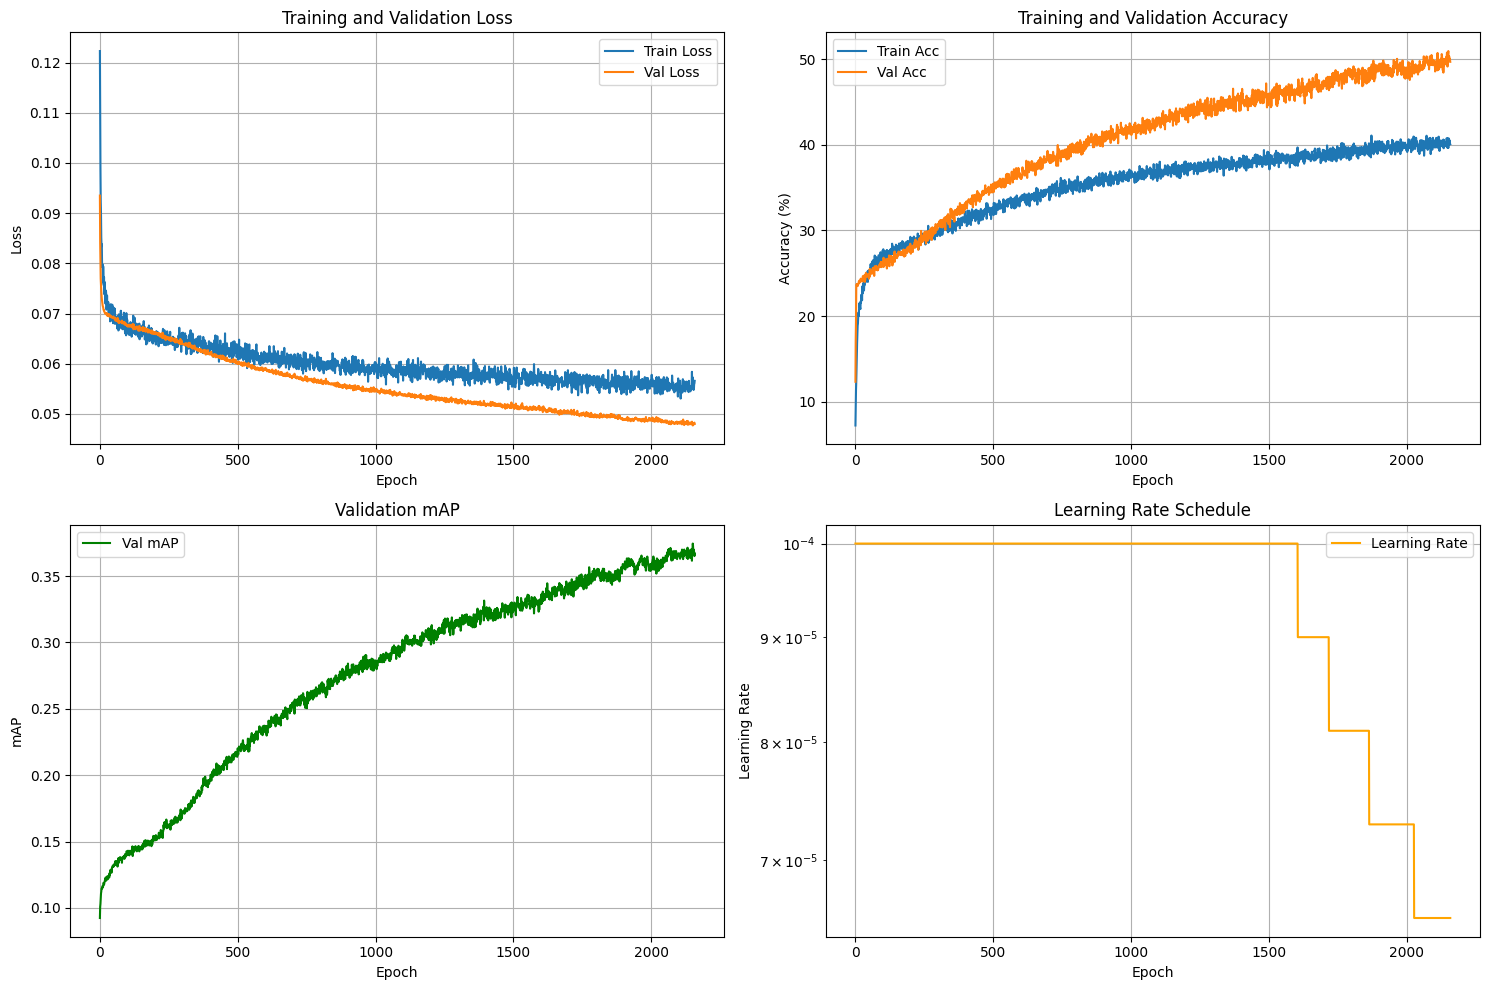

In [102]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot([x*100 for x in history['train_acc']], label='Train Acc')
    axes[0, 1].plot([x*100 for x in history['val_acc']], label='Val Acc')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(history['val_map'], label='Val mAP', color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mAP')
    axes[1, 0].set_title('Validation mAP')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(history['lr'], label='Learning Rate', color='orange')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig('training_history_unetpp.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

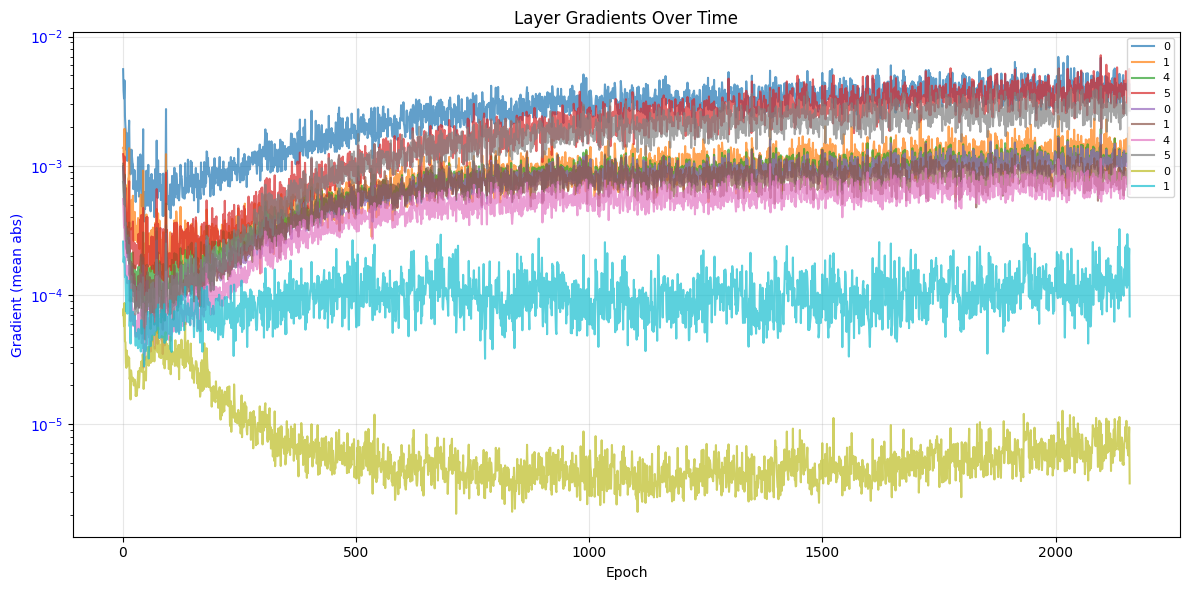

In [103]:

def plot_gradient_and_lr(history):
    if 'layer_grads' not in history or not history['layer_grads']:
        print("No gradient history found. Skipping gradient plot.")
        return

    epochs = range(1, len(history['lr']) + 1)

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Gradient (mean abs)', color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.set_title('Layer Gradients Over Time')
    ax.grid(True, alpha=0.3)

    key_layers = []
    for layer_name in history['layer_grads'].keys():
        if 'weight' in layer_name and ('conv' in layer_name or 'classifier' in layer_name or 'stem' in layer_name):
            key_layers.append(layer_name)

    if len(key_layers) > 10:
        key_layers = key_layers[:10]

    colors = plt.cm.tab10(np.linspace(0, 1, len(key_layers)))
    for i, layer_name in enumerate(key_layers):
        if layer_name in history['layer_grads']:
            short_name = layer_name.split('.')[-2] if len(layer_name.split('.')) > 2 else layer_name.split('.')[-1]
            ax.plot(epochs, history['layer_grads'][layer_name],
                    label=short_name, color=colors[i], alpha=0.7, linewidth=1.5)

    ax.legend(loc='upper right', fontsize=8)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

plot_gradient_and_lr(history)

### Test

In [120]:
def inference(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_logits = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Inference")
        for data, target in pbar:
            data = data.to(device)
            target = target.to(device)

            # Forward pass
            logits = model(data)
            loss = criterion(logits, target)

            # Compute accuracy
            preds = torch.argmax(logits, dim=1)
            correct = (preds == target).sum().item()

            # Accumulate statistics
            batch_size = target.size(0)
            total_loss += loss.item() * batch_size
            total_correct += correct
            total_samples += batch_size

            # Store results
            all_logits.append(logits.cpu())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

            # Update progress bar
            batch_acc = correct / batch_size
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{batch_acc*100:.1f}%'
            })

    # Aggregate results
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    all_logits = torch.cat(all_logits, dim=0)

    return {
        'predictions': np.array(all_preds),
        'labels': np.array(all_labels),
        'logits': all_logits,
        'avg_loss': avg_loss,
        'avg_acc': avg_acc
    }

def print_evaluation_summary(results, label_mapping=None):
    predictions = results['predictions']
    labels = results['labels']
    avg_loss = results['avg_loss']
    avg_acc = results['avg_acc']

    print(f"\nOverall Loss:     {avg_loss:.4f}")
    print(f"Overall Accuracy: {avg_acc*100:.2f}%")
    print(f"Total Samples:    {len(labels):,}")

In [121]:
checkpoint = torch.load('best_unetpp_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1}")
print(f"  Validation mAP: {checkpoint['val_map']:.4f}")
print(f"  Validation Loss: {checkpoint['val_loss']:.4f}")
print(f"  Validation Acc: {checkpoint['val_acc']*100:.2f}%\n")

Loaded model from epoch 2152
  Validation mAP: 0.3745
  Validation Loss: 0.0477
  Validation Acc: 50.94%



In [122]:
results = inference(model, test_loader, criterion, device)
print_evaluation_summary(results, label_mapping=label_mapping)

Inference: 100%|██████████| 40/40 [00:00<00:00, 82.23it/s, Loss=0.7281, Acc=22.4%]


Overall Loss:     0.0917
Overall Accuracy: 25.01%
Total Samples:    5,041


In [124]:
def get_class_names(num_classes, label_mapping=None):
    """Get class names from label mapping."""
    if label_mapping and 'idx_to_label' in label_mapping:
        idx_to_label = label_mapping['idx_to_label']
        if isinstance(list(idx_to_label.keys())[0], str):
            idx_to_label = {int(k): v for k, v in idx_to_label.items()}
        return [idx_to_label.get(i, f'Class_{i}') for i in range(num_classes)]
    return [f'Class_{i}' for i in range(num_classes)]


def compute_per_class_metrics(predictions, labels, num_classes, label_mapping=None):
    cm = confusion_matrix(labels, predictions)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    class_counts = cm.sum(axis=1)
    pred_counts = cm.sum(axis=0)

    class_names = get_class_names(num_classes, label_mapping)

    return {
        'confusion_matrix': cm,
        'class_accuracy': class_acc,
        'class_counts': class_counts,
        'pred_counts': pred_counts,
        'class_names': class_names
    }


def print_per_class_analysis(metrics):
    """Print per-class analysis."""
    cm = metrics['confusion_matrix']
    class_acc = metrics['class_accuracy']
    class_counts = metrics['class_counts']
    pred_counts = metrics['pred_counts']
    class_names = metrics['class_names']

    print(f"{'Class':<20} {'Accuracy':>10} {'True':>8} {'Pred':>8} {'Correct':>8}")
    print(f"{'-'*60}")

    for i in range(len(class_acc)):
        true_count = int(class_counts[i])
        pred_count = int(pred_counts[i])
        correct_count = int(cm[i, i])
        accuracy = class_acc[i] * 100

        print(f"{class_names[i]:<20} {accuracy:>9.2f}% {true_count:>8} {pred_count:>8} {correct_count:>8}")

    print(f"{'-'*60}")
    print(f"Mean Per-Class Acc:    {class_acc.mean()*100:.2f}%")
    print(f"Std Per-Class Acc:     {class_acc.std()*100:.2f}%")

    best_idx = class_acc.argmax()
    worst_idx = class_acc.argmin()
    print(f"\nBest Performing Class:  {class_names[best_idx]:<20} ({class_acc[best_idx]*100:.2f}%)")
    print(f"Worst Performing Class: {class_names[worst_idx]:<20} ({class_acc[worst_idx]*100:.2f}%)")


def print_classification_report(predictions, labels, label_mapping=None):
    """Print sklearn classification report."""
    num_classes = len(np.unique(labels))
    class_names = get_class_names(num_classes, label_mapping)

    print("\nClassification Report:")
    print(classification_report(
        labels, predictions,
        target_names=class_names,
        zero_division=0
    ))

In [125]:
# Compute per-class metrics
metrics = compute_per_class_metrics(
    results['predictions'],
    results['labels'],
    num_classes=n_classes,
    label_mapping=label_mapping
)

# Print per-class analysis
print_per_class_analysis(metrics)

# Print classification report
print_classification_report(
    results['predictions'],
    results['labels'],
    label_mapping=label_mapping
)

Class                  Accuracy     True     Pred  Correct
------------------------------------------------------------
Abies                     0.00%       93        0        0
Acer                      4.26%      282      124       12
Alnus                     1.62%      247       55        4
Betula                    0.36%      280        4        1
Cleared                  42.89%      422      437      181
Fagus                    20.03%      639      655      128
Fraxinus                  0.78%      255        9        2
Larix                     2.85%      316      110        9
Picea                    21.40%      570      609      122
Pinus                    62.14%      758     1377      471
Populus                   0.00%       81        0        0
Prunus                    0.00%       29        0        0
Pseudotsuga               4.32%      278      104       12
Quercus                  41.48%      769     1557      319
Tilia                     0.00%       22        0     

In [137]:
def plot_confusion_matrix(cm, label_mapping=None, num_classes=None, title='Confusion Matrix'):
    if num_classes is None:
        num_classes = cm.shape[0]

    class_names = get_class_names(num_classes, label_mapping)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count'}
    )
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_per_class_accuracy_and_counts(metrics, save_path=None):
    cm = metrics['confusion_matrix']
    class_acc = metrics['class_accuracy']
    class_counts = metrics['class_counts']
    pred_counts = metrics['pred_counts']
    class_names = metrics['class_names']

    num_classes = len(class_names)

    # Bar chart parameters
    bar_width = 0.35
    group_width = bar_width * 2
    group_spacing = 0.2

    # Calculate x positions
    x_positions = []
    for i in range(num_classes):
        start_pos = i * (group_width + group_spacing)
        x_positions.append([start_pos, start_pos + bar_width])

    # Create figure with dual y-axes
    fig, ax1 = plt.subplots(figsize=(10, 7))

    # Plot bars (true and pred counts)
    colors_bar = ['blue', 'red']  # true: blue, pred: red
    for i in range(num_classes):
        values = [class_counts[i], pred_counts[i]]
        for j, (val, color) in enumerate(zip(values, colors_bar)):
            ax1.bar(
                x_positions[i][j], val, bar_width, color=color, alpha=0.7,
                label='True' if i == 0 and j == 0 else ('Pred' if i == 0 and j == 1 else '')
            )

    ax1.set_xlabel('Class', fontsize=12)
    ax1.set_ylabel('Sample Count', fontsize=12, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_xticks([(pos[0] + pos[1]) / 2 for pos in x_positions])
    ax1.set_xticklabels(class_names, rotation=45, ha='right')
    ax1.legend(['True', 'Pred'], loc='upper left')
    ax1.grid(True, alpha=0.3, axis='y')

    # Create second y-axis for accuracy line
    ax2 = ax1.twinx()
    line_x_positions = [(pos[0] + pos[1]) / 2 for pos in x_positions]

    # Plot accuracy line
    ax2.plot(
        line_x_positions, class_acc * 100, 'o-',
        color='green', linewidth=2.5, markersize=8,
        label='Accuracy', zorder=5
    )
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.tick_params(axis='y')
    ax2.set_ylim([0, 105])
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3, linestyle='--')

    plt.title('Per-Class Accuracy and Sample Counts', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

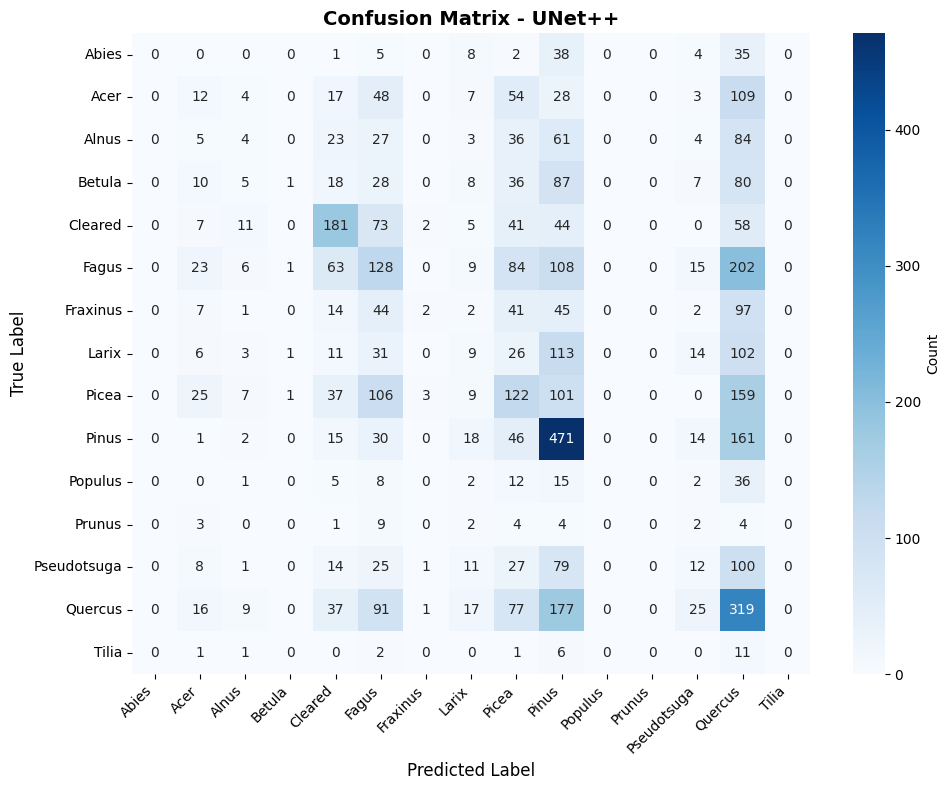

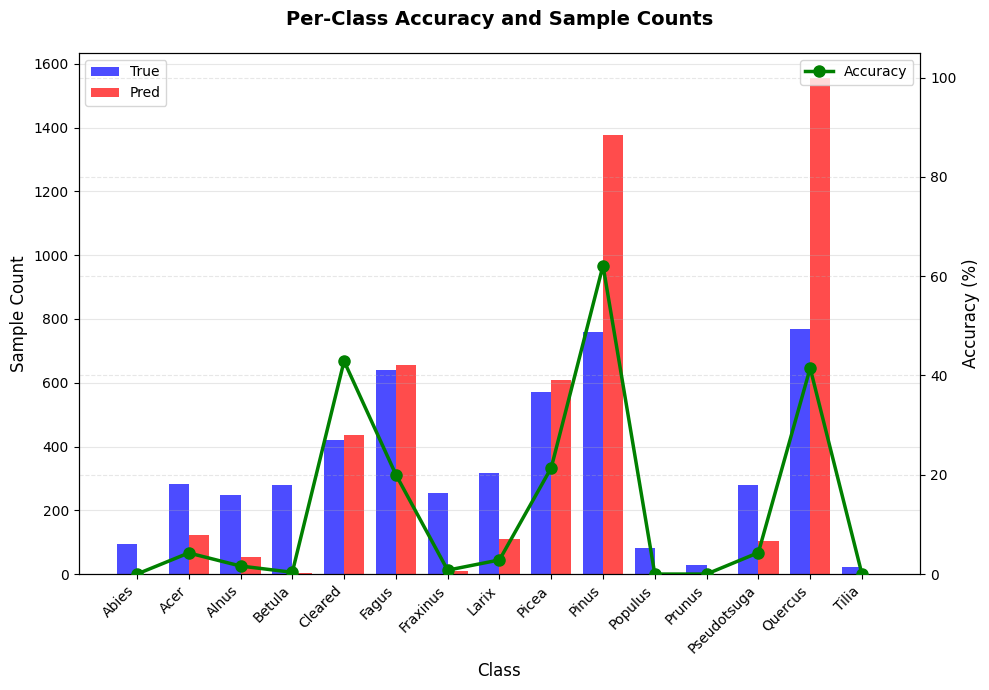

In [138]:
# Visualizations
plot_confusion_matrix(
    metrics['confusion_matrix'],
    label_mapping=label_mapping,
    num_classes=n_classes,
    title='Confusion Matrix - UNet++'
)

plot_per_class_accuracy_and_counts(
    metrics,
)